In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import load_model
import pickle

In [2]:
model = load_model('best_model.keras', compile=False)
model.compile(optimizer='adam', loss='mse')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')
with open('target_scaler.pkl', 'rb') as f:
    target_scaler = pickle.load(f)
df = pd.read_csv('final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

In [3]:
predictions_scaled = model.predict(X_test)
predictions_real = target_scaler.inverse_transform(predictions_scaled)
actual_real = target_scaler.inverse_transform(y_test)
predictions_flat = predictions_real.flatten()
actual_flat      = actual_real.flatten()
print('First 5 results:')
for i in range(5):
    predicted = round(predictions_flat[i], 2)
    actual    = round(actual_flat[i], 2)
    diff      = round(abs(predicted - actual), 2)
    print('  Predicted: $' + str(predicted),
          ' | Actual: $' + str(actual),
          ' | Difference: $' + str(diff))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
First 5 results:
  Predicted: $200.29  | Actual: $212.45  | Difference: $12.16
  Predicted: $203.53  | Actual: $207.88  | Difference: $4.35
  Predicted: $204.86  | Actual: $205.71  | Difference: $0.85
  Predicted: $204.25  | Actual: $206.35  | Difference: $2.1
  Predicted: $203.6  | Actual: $207.27  | Difference: $3.67


In [4]:
mse  = mean_squared_error(actual_flat, predictions_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_flat, predictions_flat)
r2 = r2_score(actual_flat, predictions_flat)
mape = np.mean(np.abs((actual_flat - predictions_flat) / actual_flat)) * 100
print(' Model Evaluation Metric')
print('RMSE:', round(rmse, 4), 'USD')
print('MAE :', round(mae,  4), 'USD')
print('R2 :', round(r2,   4), '(closer to 1.0 is better)')
print('MAPE:', round(mape, 4), '%')
print('In simple English:')
print('On average the model is $' + str(round(mae, 2)) + ' off from the actual price')
print('The model explains ' + str(round(r2 * 100, 2)) + '% of the variation in Apple stock price')

 Model Evaluation Metric
RMSE: 11.3954 USD
MAE : 9.6925 USD
R2 : 0.7657 (closer to 1.0 is better)
MAPE: 4.1721 %
In simple English:
On average the model is $9.69 off from the actual price
The model explains 76.57% of the variation in Apple stock price


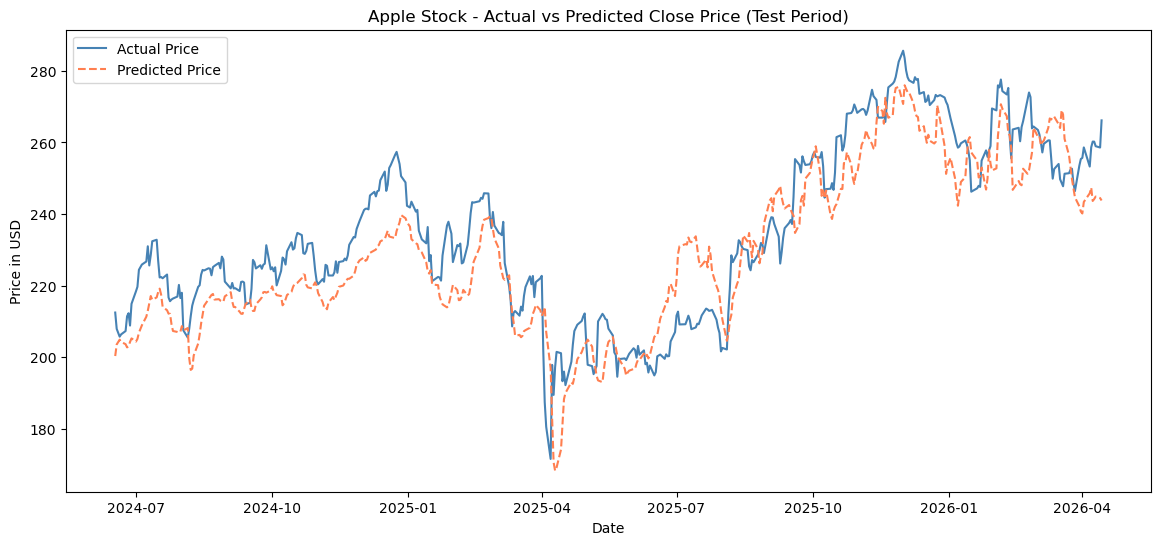

Insight: The closer the two lines the better the model performed


In [5]:
# Get the dates for the test period
total_rows = len(df)
train_size = int(total_rows * 0.80)

# Skip first 60 rows of test set (used as first window)
test_dates = df['date'].iloc[train_size + 60:].reset_index(drop=True)

# Make sure lengths match
min_length = min(len(test_dates), len(predictions_flat), len(actual_flat))
test_dates       = test_dates[:min_length]
predictions_flat = predictions_flat[:min_length]
actual_flat      = actual_flat[:min_length]

plt.figure(figsize=(14, 6))

# Plot actual prices
plt.plot(test_dates, actual_flat,
         color='steelblue', linewidth=1.5, label='Actual Price')

# Plot predicted prices
plt.plot(test_dates, predictions_flat,
         color='coral', linewidth=1.5, linestyle='--', label='Predicted Price')

plt.title('Apple Stock - Actual vs Predicted Close Price (Test Period)')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.savefig('phase5_plot1_actual_vs_predicted.png')
plt.show()

print('Insight: The closer the two lines the better the model performed')

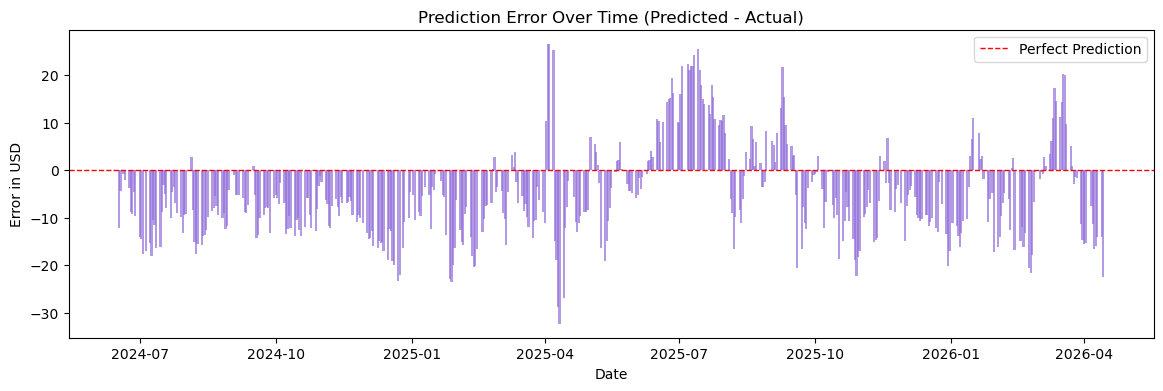

In [6]:
errors = predictions_flat - actual_flat

plt.figure(figsize=(14, 4))
plt.bar(test_dates, errors, color='mediumpurple', alpha=0.7, width=1.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Perfect Prediction')
plt.title('Prediction Error Over Time (Predicted - Actual)')
plt.xlabel('Date')
plt.ylabel('Error in USD')
plt.legend()
plt.show()